In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
## import des librairie necessaires :

import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns
import tensorflow as tf
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## classification supervisé de machine learning avec modele MLPClassifier pour Chaque objet du dataset et en integrant la segmentation et l'extraction du features et aussi l'augmentation des image avec anomalies:

Dans cette partie nous avons choisis de faire une classification supervisée en machine learning avec le modele MLPClassifier  pour chaque objet en integrant de la segmentation.

#### **`1. Modele pour cable:`**

Dans cette partie, nous alons faire un modele pour la categorie cable afin de voir si notre approche permet d'obtenir un modele perfermant qui arrive à classer la classe des anomalies avec une bonne precision et un bon rappel aussi.

###### **`Segmentation:`**

Pour chaque catégorie du jeu de données MVTec, une analyse visuelle a permis d’identifier la nature dominante des défauts. Les défauts chromatiques ont été traités par une segmentation basée sur la couleur, tandis que les défauts structurels ont été traités par une segmentation basée sur les contours. Lorsque les défauts sont internes ou purement texturels, aucune segmentation n’a été appliquée.

| Catégorie MVTec | Type de catégorie | Type dominant de défaut         | Segmentation recommandée |
| --------------- | ----------------- | ------------------------------- | ------------------------ |
| **carpet**      | Texture           | Texture / couleur diffuse       | **Couleur**              |
| **grid**        | Texture           | Structure (lignes cassées)      | **Contours**             |
| **leather**     | Texture           | Couleur / texture               | **Couleur**              |
| **tile**        | Texture           | Couleur / motif                 | **Couleur**              |
| **wood**        | Texture           | Couleur / texture               | **Couleur**              |
| **bottle**      | Objet             | Texture interne / contamination | **Aucune**               |
| **cable**       | Objet             | Structure / coupure             | **Contours**             |
| **capsule**     | Objet             | Couleur / texture               | **Couleur**              |
| **hazelnut**    | Objet             | Couleur (zones brunies)         | **Couleur**              |
| **metal_nut**   | Objet             | Forme / géométrie               | **Contours**             |
| **pill**        | Objet             | Couleur / surface               | **Couleur**              |
| **screw**       | Objet             | Forme / orientation             | **Contours**             |
| **toothbrush**  | Objet             | Forme / structure               | **Contours**             |
| **transistor**  | Objet             | Structure / composants          | **Contours**             |
| **zipper**      | Objet             | Structure (dents manquantes)    | **Contours**             |


Cette fonction réalise une segmentation par couleur.
Son but est de conserver uniquement les zones colorées de l’image et de supprimer les zones peu colorées (blanc, gris, noir, ombres).


La segmentation repose sur la saturation des couleurs :

Une couleur “forte” → saturation élevée

Une couleur “fade”, gris ou blanc → saturation faible

On utilise donc la composante S (Saturation) pour décider quels pixels garder.

In [ ]:
def segment_color_simple(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    mask = (s > 30).astype("uint8") * 255
    return cv2.bitwise_and(img, img, mask=mask)


Cette fonction réalise une segmentation basée sur les contours.
Son but est de :

* Détecter l’objet principal dans l’image
* Découper l’image pour ne garder que la zone de cet objet

In [ ]:
def segment_contour_simple(img):
    # Si l'image est déjà en niveaux de gris
    if img.ndim == 2:
        gray = img
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    return img[y:y+h, x:x+w]

In [ ]:
SEGMENTATION_BY_CATEGORY = {
    "grid": "none",
    "cable": "contour",
    "screw": "contour",
    "zipper": "contour",
    "metal_nut": "contour",

    "wood": "color",
    "leather": "color",
    "tile": "color",
    "carpet": "color",
    "pill": "color",
    "hazelnut": "color",
    "capsule": "color",

    "bottle": "none",
}


In [ ]:
##choisir la segmentation à appliquer

def apply_segmentation(img, category):
    mode = SEGMENTATION_BY_CATEGORY.get(category, "none")

    if mode == "contour":
        return segment_contour_simple(img)

    elif mode == "color":
        return segment_color_simple(img)

    else:  # "none"
        return img


**Justification des choix de segmentation par categorie:**

| Catégorie      | Type    | Segmentation choisie | Pourquoi ce choix est pertinent                                                                                                                                                                |
| -------------- | ------- | -------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **carpet**     | Texture | Couleur              | Les défauts apparaissent comme des variations chromatiques et de texture réparties sur la surface. La segmentation couleur permet d’isoler les zones anormales et de réduire le bruit du fond. |
| **grid**       | Texture | Contours             | Les défauts se traduisent par des ruptures de lignes et des discontinuités structurelles. La segmentation par contours met en évidence ces anomalies géométriques.                             |
| **leather**    | Texture | Couleur              | Les défauts correspondent principalement à des décolorations et des irrégularités de surface visibles par la couleur.                                                                          |
| **tile**       | Texture | Couleur              | Les anomalies modifient les motifs et la teinte des carreaux. La segmentation couleur permet de détecter ces différences chromatiques.                                                         |
| **wood**       | Texture | Couleur              | Les défauts (taches, brûlures) sont principalement de nature chromatique et se distinguent par la couleur.                                                                                     |
| **bottle**     | Objet   | Aucune               | L’objet est centré sur fond uniforme et les défauts sont internes. Une segmentation pourrait supprimer des informations utiles.                                                                |
| **cable**      | Objet   | Contours             | Les défauts affectent la structure du câble (coupures, déformations). La segmentation par contours permet d’isoler la forme.                                                                   |
| **capsule**    | Objet   | Couleur              | Les défauts se manifestent par des variations de couleur et de texture sur la surface.                                                                                                         |
| **hazelnut**   | Objet   | Couleur              | Les anomalies sont visibles sous forme de zones brunies ou décolorées, donc chromatiques.                                                                                                      |
| **metal_nut**  | Objet   | Contours             | Les défauts modifient la géométrie et les arêtes de l’objet métallique. Les contours sont discriminants.                                                                                       |
| **pill**       | Objet   | Couleur              | Les anomalies correspondent à des différences de teinte et d’aspect de surface.                                                                                                                |
| **screw**      | Objet   | Contours             | Les défauts entraînent des déformations de la vis, visibles au niveau de la forme et des bords.                                                                                                |
| **toothbrush** | Objet   | Contours             | Les anomalies affectent la structure et l’alignement de l’objet.                                                                                                                               |
| **transistor** | Objet   | Contours             | Les défauts sont liés à la disposition et à la forme des composants.                                                                                                                           |
| **zipper**     | Objet   | Contours             | Les anomalies se manifestent par des dents manquantes ou mal alignées, donc structurelles.                                                                                                     |


###### **`Appliquer une extraction de feature :`**

La règle de base (débutant)

Pour un type d’objet, on choisit l’extraction de features selon la propriété la plus stable et la plus discriminante :

* Couleur / teinte dominante → extract_color_features (histogrammes HSV)

* Texture / motif répétitif → extract_lbp_features (LBP)

* Forme / bords / structure → extract_hog_features (HOG)

L’objectif est d’avoir un vecteur qui sépare bien “normal” vs “anormal” pour cet objet, sans être trop sensible aux variations inutiles (luminosité, petits décalages, etc.).

1) Pourquoi choisir les features couleur (HSV histogrammes) ?
Quand c’est pertinent

Matériaux avec couleur/teinte caractéristique : wood, leather, tile, carpet, pill, hazelnut, capsule…

Quand les anomalies changent souvent :

* la teinte (H)

* la saturation (S) (tache, décoloration, zone “fade”)

Pourquoi HSV (H & S)

* H capture “quelle couleur”

* S capture “à quel point c’est coloré”

* Ça évite de trop dépendre de la luminosité (V) → plus robuste.

En résumé : si l’objet se reconnaît surtout par sa couleur / matière colorée, l’histogramme HSV est un bon choix.

In [ ]:
def extract_color_features(img, bins=16):
    """
    Histogrammes couleur simples (HSV).
    Retourne un vecteur 1D normalisé.
    """
    # Si image en gris = pas de couleur
    if img.ndim == 2:
        return np.zeros(bins * 2, dtype=np.float32)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist_h = cv2.calcHist([hsv], [0], None, [bins], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [bins], [0, 256])

    hist = np.concatenate([hist_h, hist_s]).flatten()
    hist = hist / (hist.sum() + 1e-8)

    return hist.astype(np.float32)


2) Pourquoi choisir les features texture (LBP) ?
Quand c’est pertinent

Surfaces avec motifs et micro-textures :

* carpet, tile, leather, wood (souvent)

Anomalies typiques :

* rayures fines

* trous

* zones rugueuses / lisses anormales

* changements locaux de texture

Pourquoi LBP

LBP compare chaque pixel à ses voisins → il décrit des patterns locaux (grain, rugosité) et fait un histogramme global.

En résumé : si le “grain” ou le motif du matériau est l’information la plus importante, LBP est souvent plus discriminant que la couleur.

In [ ]:
def extract_lbp_features(img):
    """
    LBP simple (8 voisins) + histogramme.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    gray = gray.astype(np.uint8)
    h, w = gray.shape

    lbp = np.zeros((h, w), dtype=np.uint8)

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            center = gray[y, x]
            code = 0
            code |= (gray[y-1, x-1] >= center) << 7
            code |= (gray[y-1, x  ] >= center) << 6
            code |= (gray[y-1, x+1] >= center) << 5
            code |= (gray[y,   x+1] >= center) << 4
            code |= (gray[y+1, x+1] >= center) << 3
            code |= (gray[y+1, x  ] >= center) << 2
            code |= (gray[y+1, x-1] >= center) << 1
            code |= (gray[y,   x-1] >= center) << 0
            lbp[y, x] = code

    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256))
    hist = hist.astype(np.float32)
    hist = hist / (hist.sum() + 1e-8)

    return hist


3) Pourquoi choisir les features forme/bords (HOG) ?
Quand c’est pertinent

Objets où la géométrie et les bords dominent :

screw, cable, zipper, grid, metal_nut…

Anomalies typiques :

* déformation de forme

* pièce manquante / cassée

* mauvais alignement / partie tordue

* contour anormal

Pourquoi HOG

HOG résume les orientations de gradients (les directions des bords) sur des cellules → excellent pour décrire structure + forme, même si la couleur change peu.

En résumé : si l’objet est surtout “une forme” avec des contours nets, HOG est généralement plus adapté que la couleur.

In [ ]:
def extract_hog_features(img):
    """
    HOG simple avec OpenCV.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    gray = cv2.resize(gray, (128, 128))

    hog = cv2.HOGDescriptor(
        _winSize=(128, 128),
        _blockSize=(16, 16),
        _blockStride=(8, 8),
        _cellSize=(8, 8),
        _nbins=9
    )

    features = hog.compute(gray)
    return features.flatten().astype(np.float32)


In [ ]:
def extract_features(img, category):
    features = []

    if category in ["wood", "leather", "tile", "carpet", "pill", "hazelnut", "capsule"]:
        features.append(extract_color_features(img))
        features.append(extract_lbp_features(img))

    elif category in ["grid", "cable", "screw", "zipper", "metal_nut",
                      "toothbrush", "transistor"]:
        features.append(extract_hog_features(img))

    elif category == "bottle":
        features.append(extract_lbp_features(img))
        features.append(extract_hog_features(img))

    else:
        features.append(extract_lbp_features(img))

    return np.concatenate(features)


Dans le tableau ci-dessous nous avons detaillé et justifier les choix des extraction de feature utilisé pour chaque categorie:

| Catégorie      | Type (Texture / Objet) | Type dominant de défaut         | Segmentation choisie | Features recommandées | Justification                                               |
| -------------- | ---------------------- | ------------------------------- | -------------------- | --------------------- | ----------------------------------------------------------- |
| **carpet**     | Texture                | Texture / couleur diffuse       | Couleur              | Couleur + LBP         | Défauts visibles par variations chromatiques et texturelles |
| **grid**       | Texture                | Structure (lignes cassées)      | Contours             | HOG                   | Les anomalies sont des ruptures géométriques                |
| **leather**    | Texture                | Couleur / texture               | Couleur              | Couleur + LBP         | Défauts visibles par décoloration et texture                |
| **tile**       | Texture                | Motif / couleur                 | Couleur              | Couleur + LBP         | Changements de motif et de teinte                           |
| **wood**       | Texture                | Couleur / texture               | Couleur              | Couleur + LBP         | Taches et brûlures chromatiques                             |
| **bottle**     | Objet                  | Texture interne / contamination | Aucune               | LBP + HOG             | Défauts internes détectables par texture                    |
| **cable**      | Objet                  | Structure / coupure             | Contours             | HOG                   | Défauts de forme et de continuité                           |
| **capsule**    | Objet                  | Couleur / texture               | Couleur              | Couleur + LBP         | Variations chromatiques de surface                          |
| **hazelnut**   | Objet                  | Couleur (zones brunies)         | Couleur              | Couleur + LBP         | Anomalies visibles par la teinte                            |
| **metal_nut**  | Objet                  | Géométrie / arêtes              | Contours             | HOG                   | Défauts affectant la forme                                  |
| **pill**       | Objet                  | Couleur / surface               | Couleur              | Couleur + LBP         | Défauts chromatiques et texturels                           |
| **screw**      | Objet                  | Forme / orientation             | Contours             | HOG                   | Déformations de la vis                                      |
| **toothbrush** | Objet                  | Structure                       | Contours             | HOG                   | Défauts géométriques                                        |
| **transistor** | Objet                  | Structure / composants          | Contours             | HOG                   | Disposition anormale des composants                         |
| **zipper**     | Objet                  | Structure (dents manquantes)    | Contours             | HOG                   | Ruptures dans la structure des dents                        |


###### **`Appliquer les preprocissing et création de X et y à partir des données de train et test :`**

In [ ]:
## préprocessing: Création des dossiers X et y avec les données train et test melangé dans X et les labels dans y:
## Fonction qui permet de faire les preprocessing necessaires:

def Dataset_supervise (path, category):

    """ fonction qui permet de regrouper


              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {category} : {len(img_paths)}")



    ## Lire les images sans les convertir en gris
    for file_path in img_paths:
      img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
      if img is None:
        continue
      if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)



      ##redimentionnement des taille:
      img=cv2.resize(img, (256,256))


      # SEGMENTATION: ajouter une condition pour lancer lensembel des categorie
      img = apply_segmentation(img, category)

      # remettre à taille fixe après segmentation
      img = cv2.resize(img, (256, 256))

      #EXTRACTION DE FEATURES
      #feature = extract_features(img, category)


      ##ajouter le resultats dans la liste :
      img_prp.append(img)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X





###### **`Creation de X et y  :`**

In [ ]:
##Appliquer les preprocessing pour l'ensemble des données de train/ good:

## pour cela nous allons utiliser la methode glob pour lire les fichier de train de l'ensemble des pieces :

path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good"
train_path= glob(path)

X_train_grid= []
y_train_grid=[]
for category_path in train_path:
  category = os.path.basename(os.path.dirname(os.path.dirname(category_path)))
  X_cate= Dataset_supervise(category_path,category)
  y_anom = np.zeros(len(X_cate), dtype=np.int64)
  X_train_grid.append(X_cate)
  y_train_grid.append(y_anom)

X_train_grid= np.concatenate(X_train_grid, axis=0)
y_train_grid= np.concatenate(y_train_grid, axis=0)
print("X_train_good:", X_train_grid.shape)
print("y_train_good:", y_train_grid.shape, "labels:", np.unique(y_train_grid))

Nombre d'images trouvées dans grid : 264
X_train_good: (264, 256, 256)
y_train_good: (264,) labels: [0]


In [ ]:
## liste pour stocker X_test et y_test
X_test_grid= []
y_test_grid= []


## chemin du dataset:
path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/grid")

##faire une boucle pour créer
for cat in categories:
    category = os.path.basename(cat)
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test_grid.append(X_good)
        y_test_grid.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chauq piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = Dataset_supervise(anomaly_path, category)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test_grid.append(X_anom)
            y_test_grid.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test_grid = np.concatenate(X_test_grid, axis=0)
y_test_grid = np.concatenate(y_test_grid, axis=0)

print(X_test_grid.shape, y_test_grid.shape)


Nombre d'images trouvées dans grid : 21
Nombre d'images trouvées dans grid : 12
Nombre d'images trouvées dans grid : 12
Nombre d'images trouvées dans grid : 11
Nombre d'images trouvées dans grid : 11
Nombre d'images trouvées dans grid : 11
(78, 256, 256) (78,)


In [ ]:
##fusion des données test avec train pour créer les dossier X et y:
X = np.concatenate([X_train_grid, X_test_grid], axis=0)
y = np.concatenate([y_train_grid, y_test_grid], axis=0)

print(X.shape, y.shape)


(342, 256, 256) (342,)


##### **`Instanciation d'un modele MLPClassifier:`**

In [ ]:
from sklearn.model_selection import train_test_split
## Applatir les données de X:
X_flat = X.reshape(X.shape[0], -1)

##spliter en données d'entrainnement et de test on laissant 20% pour les données test:

X_train, X_test, y_train, y_test= train_test_split(X_flat, y, test_size=0.2, random_state=42)

## Standardiser X_train et X_test:

Scale= StandardScaler()
X_train = Scale.fit_transform(X_train)
X_test = Scale.transform(X_test)

##### **` une Couche caché avec 10 neurones`**

In [ ]:
 # 1 couche cachée de 10 neurones
mlp = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',solver='adam',max_iter=300,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.8405797101449275
classe predicte   0  1
calsse réelle         
0                55  4
1                 7  3
                   pre       rec       spe        f1       geo       iba       sup

          0       0.89      0.93      0.30      0.91      0.53      0.30        59
          1       0.43      0.30      0.93      0.35      0.53      0.26        10

avg / total       0.82      0.84      0.39      0.83      0.53      0.29        69



**` une Couche caché avec 100 neurones`**

In [ ]:
 # 1 couche cachée de 100 neurones
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu',solver='adam',max_iter=300,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.7536231884057971
classe predicte   0   1
calsse réelle          
0                49  10
1                 7   3
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.83      0.30      0.85      0.50      0.26        59
          1       0.23      0.30      0.83      0.26      0.50      0.24        10

avg / total       0.78      0.75      0.38      0.77      0.50      0.26        69



 **`2 couche cachée:`**

In [ ]:
 # 2 couche cachée:
mlp = MLPClassifier(hidden_layer_sizes=(100,64), activation='relu',solver='adam',max_iter=300,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.8405797101449275
classe predicte   0  1
calsse réelle         
0                56  3
1                 8  2
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.95      0.20      0.91      0.44      0.20        59
          1       0.40      0.20      0.95      0.27      0.44      0.18        10

avg / total       0.81      0.84      0.31      0.82      0.44      0.20        69



**` 3 couche cachée:`**

In [ ]:
 # 3 couche cachée:
mlp = MLPClassifier(hidden_layer_sizes=(100,64,32), activation='relu',solver='adam',max_iter=300,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.782608695652174
classe predicte   0  1
calsse réelle         
0                51  8
1                 7  3
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.86      0.30      0.87      0.51      0.27        59
          1       0.27      0.30      0.86      0.29      0.51      0.24        10

avg / total       0.79      0.78      0.38      0.79      0.51      0.27        69



**` 2 couche cachée avec changement d'hyperparametre:`**

In [ ]:
 # 2 couche cachée:
mlp = MLPClassifier(hidden_layer_sizes=(100,64), activation='relu',solver='adam',max_iter=800,early_stopping=True,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.8260869565217391
classe predicte   0  1
calsse réelle         
0                53  6
1                 6  4
                   pre       rec       spe        f1       geo       iba       sup

          0       0.90      0.90      0.40      0.90      0.60      0.38        59
          1       0.40      0.40      0.90      0.40      0.60      0.34        10

avg / total       0.83      0.83      0.47      0.83      0.60      0.37        69



##### **`Augmentation des données test: `**

In [ ]:

def augment_test(img):
    """Augmentation légère pour images anormales (gray, shape HxW)."""
    out = img.copy()
    h, w = out.shape[:2]

    # 1) rotation légère
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-7, 7)
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2) translation légère
    if np.random.rand() < 0.5:
        tx = np.random.uniform(-0.05*w, 0.05*w)
        ty = np.random.uniform(-0.05*h, 0.05*h)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 3) bruit gaussien léger
    if np.random.rand() < 0.4:
        out_f = out.astype(np.float32) / 255.0
        noise = np.random.normal(0, 0.02, out.shape).astype(np.float32)
        out_f = np.clip(out + noise, 0, 1)
        out = (out_f * 255.0).astype(np.uint8)

    # 4) variation de luminosité légère
    if np.random.rand() < 0.4:
        factor = np.random.uniform(0.9, 1.1)

     ##Si couleur, on ajuste la luminosité via HSV (canal V)
        if out.ndim == 3 and out.shape[2] == 3:
          hsv = cv2.cvtColor(out, cv2.COLOR_BGR2HSV)
          hsv = hsv.astype(np.float32)
          hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
          out = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
        else:
        # Image grise
          out_f = out.astype(np.float32)
          out_f = np.clip(out_f * factor, 0, 255)
          out = out_f.astype(np.uint8)


    return out



In [ ]:
## préprocessing: Création des dossiers X et y avec les données train et test melangé dans X et les labels dans y:
## Fonction qui permet de faire les preprocessing necessaires:

def Dataset_supervise (path, category, do_augment=False, k=0):

    """ Dans cette fonction on ajoute l'augmentation de la données des test :


              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {os.path.join(path, category)} : {len(img_paths)}")



    ## Lire les images sans les convertir en gris
    for file_path in img_paths:
      img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
      if img is None:
        continue
      if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

      ##redimentionnement des taille:
      img=cv2.resize(img, (256,256))



      # SEGMENTATION: ajouter une condition pour lancer lensembel des categorie
      img = apply_segmentation(img, category)

      # remettre à taille fixe après segmentation
      img = cv2.resize(img, (256, 256))



      #EXTRACTION DE FEATURES
      #feature = extract_features(img, category)


      ##ajouter le resultats dans la liste :
      img_prp.append(img)

      # AUGMENTATIONS (k nouvelles images) ---
      if do_augment and k > 0:
        for _ in range(k):
          img_aug = augment_test(img)  # part de l'original à chaque fois
          img_aug = apply_segmentation(img_aug, category)
          img_aug = cv2.resize(img_aug, (256, 256))
          #feat_aug = extract_features(img_aug, category)
          img_prp.append(img_aug)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X





In [ ]:
## liste pour stocker X_test et y_test
X_test_grid_aug= []
y_test_grid_aug= []


## chemin du dataset:
path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/grid")

##faire une boucle pour créer
for cat in categories:
    category = os.path.basename(cat)
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category, do_augment=True, k=0)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test_grid_aug.append(X_good)
        y_test_grid_aug.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chauq piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = Dataset_supervise(anomaly_path, category, do_augment=True, k=6)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test_grid_aug.append(X_anom)
            y_test_grid_aug.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test_grid_aug = np.concatenate(X_test_grid_aug, axis=0)
y_test_grid_aug = np.concatenate(y_test_grid_aug, axis=0)

print(X_test_grid_aug.shape, y_test_grid_aug.shape)


Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/good/grid : 21
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/bent/grid : 12
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/broken/grid : 12
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/thread/grid : 11
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/metal_contamination/grid : 11
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/glue/grid : 11
(420, 256, 256) (420,)


In [ ]:
print(Counter(y_test_grid_aug))

Counter({np.int64(1): 399, np.int64(0): 21})


In [ ]:
##fusion des données test avec train pour créer les dossier X et y:
X = np.concatenate([X_train_grid, X_test_grid_aug], axis=0)
y = np.concatenate([y_train_grid, y_test_grid_aug], axis=0)

print(X.shape, y.shape)

(684, 256, 256) (684,)


In [ ]:
from collections import Counter
print(Counter(y))

Counter({np.int64(1): 399, np.int64(0): 285})


#### **`Instancier le MLPClassifier aprés augmentation de la données:`**

In [ ]:
from sklearn.model_selection import train_test_split
## Applatir les données de X:

X_flat = X.reshape(X.shape[0], -1)
##spliter en données d'entrainnement et de test on laissant 20% pour les données test:

X_train, X_test, y_train, y_test= train_test_split(X_flat, y, test_size=0.2, random_state=42)

## Standardiser X_train et X_test:

Scale= StandardScaler()
X_train = Scale.fit_transform(X_train)
X_test = Scale.transform(X_test)

In [ ]:
 # 2 couche cachée:
mlp = MLPClassifier(hidden_layer_sizes=(100,64), activation='relu',solver='adam',max_iter=800,early_stopping=True,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.7654320987654321
classe predicte   0   1
calsse réelle          
0                56  24
1                14  68
                   pre       rec       spe        f1       geo       iba       sup

          0       0.80      0.70      0.83      0.75      0.76      0.57        80
          1       0.74      0.83      0.70      0.78      0.76      0.59        82

avg / total       0.77      0.77      0.76      0.76      0.76      0.58       162



In [ ]:
 # 2 couche cachée: avec ce modele nous avons augmenter uniquement les image avec anomalies
mlp = MLPClassifier(hidden_layer_sizes=(100,64), activation='relu',solver='adam',max_iter=800,early_stopping=True,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.8029197080291971
classe predicte   0   1
calsse réelle          
0                55   9
1                18  55
                   pre       rec       spe        f1       geo       iba       sup

          0       0.75      0.86      0.75      0.80      0.80      0.65        64
          1       0.86      0.75      0.86      0.80      0.80      0.64        73

avg / total       0.81      0.80      0.81      0.80      0.80      0.65       137



##### **`Tester plusieurs modeles avec searchGrid:`**

In [ ]:
# Définir les modèles
models = {
    'MLPClassifier': MLPClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'SVC': SVC()
}

# Hyperparamètres à tester pour chaque modèle
param_grids = {
        'MLPClassifier': {
        'hidden_layer_sizes': [(64,), (128, 64), (128, 64, 32)],
        'alpha': [1e-4, 1e-3, 1e-2],
        'learning_rate_init': [1e-4, 1e-3],
        'activation': ['relu', 'tanh'] },

    'RandomForestClassifier':
        {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, 30]},

    'SVC':
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
}

# Dictionnaire pour stocker les résultats
results = {}

In [ ]:
def compare_search_methods(model_name, model, param_grid):
    search_methods = {
        'GridSearchCV': GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=5,
            scoring='accuracy'
        ),

        'BayesSearchCV': BayesSearchCV(
            estimator=model,
            search_spaces=param_grid,
            n_iter=5,
            cv=5,
            scoring='accuracy',
            random_state=42
        )
    }

    results[model_name] = {}

    for search_name, search in search_methods.items():
        # Entraînement
        search.fit(X_train, y_train)

        # Meilleurs paramètres
        best_params = search.best_params_
        best_score = search.best_score_

        # Prédictions test
        y_pred = search.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_pred)

        #  MATRICE DE CONFUSION
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=search.classes_
        )

        disp.plot(cmap="Blues", values_format="d")
        plt.title(f"{model_name} - {search_name}")
        plt.show()

        # RAPPORT IMBALANCED
        print("=" * 60)
        print(f"Classification report (imbalanced) — {model_name} / {search_name}")
        print(classification_report_imbalanced(y_test, y_pred))
        print("=" * 60)


        # Sauvegarde résultats
        results[model_name][search_name] = {
            'best_params': best_params,
            'best_cv_score': best_score,
            'test_accuracy': test_accuracy,
            'confusion_matrix': cm
        }


/usr/local/lib/python3.12/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [0.0001, 0.001] was inferred to Real(low=0.0001, high=0.001, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0.0001, 0.001), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(


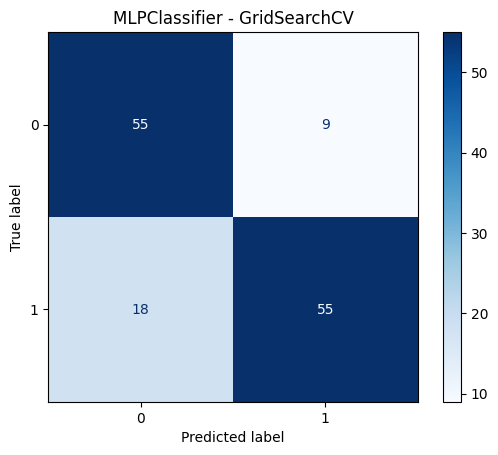

Classification report (imbalanced) — MLPClassifier / GridSearchCV
                   pre       rec       spe        f1       geo       iba       sup

          0       0.75      0.86      0.75      0.80      0.80      0.65        64
          1       0.86      0.75      0.86      0.80      0.80      0.64        73

avg / total       0.81      0.80      0.81      0.80      0.80      0.65       137



/usr/local/lib/python3.12/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [0.0001, 0.001] was inferred to Real(low=0.0001, high=0.001, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0.0001, 0.001), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [0.0001, 0.001] was inferred to Real(low=0.0001, high=0.001, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0.0001, 0.001), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(


ValueError: can only convert an array of size 1 to a Python scalar

In [ ]:
# Exécuter la comparaison pour chaque modèle
for model_name, model in models.items():
    compare_search_methods(model_name, model, param_grids[model_name])

# Afficher les résultats
for model_name, model_results in results.items():
    print("=" * 80)
    print(f"Model: {model_name}")
    print("=" * 80)

    for search_name, search_results in model_results.items():
        print(f"\n🔹 {search_name}")
        print(f"Best Params      : {search_results['best_params']}")
        print(f"Best CV Score    : {search_results['best_cv_score']:.2f}")
        print(f"Test Accuracy    : {search_results['test_accuracy']:.2f}")

        print("\nClassification report (imbalanced):")
        print(search_results['report_imbalanced'])

    print("\n")
